## Phase 4: Aesthetic RGB Image Creation (Automated Advanced Pipeline)
This notebook applies professional astrophotography techniques (LRGB sharpening, dynamic 2D background extraction, morphological star reduction, and selective curves) to flux-calibrated FITS files using automated image statistics.

In [52]:
# CELL 1: Imports and Setup
import numpy as np
from astropy.io import fits
import astroalign as aa
from astropy.visualization import make_lupton_rgb
from photutils.background import Background2D, MedianBackground
from scipy.ndimage import gaussian_filter, minimum_filter
from skimage import color
import matplotlib.pyplot as plt
import warnings
import os

# Ignore warnings from arrays containing NaNs or specific math anomalies common in edge-pixels
warnings.filterwarnings('ignore')

# Set plot parameters for large, high-res inline images
plt.rcParams['figure.figsize'] = (15, 15)
plt.rcParams['image.origin'] = 'lower'

print("Advanced Astrophotography Libraries loaded successfully!")

Advanced Astrophotography Libraries loaded successfully!


In [53]:
# CELL 2: Define File Paths
# Replace these with the actual paths to your Phase 3 flux-calibrated FITS files.
# We map R -> Red, V -> Green, and B -> Blue.

base_dir = "/media/plato/imtiaz/image_processing/NGC7331_thairobotic/Flux_calibrated"

r_file = os.path.join(base_dir, "Master_NGC7331_R_Photo_Andor_DU934P_BV_60s_5fr_fluxcal.fits")
g_file = os.path.join(base_dir, "Master_NGC7331_V_Photo_Andor_DU934P_BV_60s_4fr_fluxcal.fits")
b_file = os.path.join(base_dir, "Master_NGC7331_B_Photo_Andor_DU934P_BV_60s_5fr_fluxcal.fits")

print("File paths configured.")

File paths configured.


In [54]:
# CELL 3: Load the Linear Flux-Calibrated Data
print("Loading FITS data into memory...")

# NOTE: FITS files are natively "Big-Endian" byte order, but modern processors 
# and libraries like Astroalign expect "Little-Endian". 
# We use .astype(float) to force the conversion and prevent buffer errors.
r_data = fits.getdata(r_file).astype(float)
g_data = fits.getdata(g_file).astype(float)
b_data = fits.getdata(b_file).astype(float)

print(f"Red channel shape: {r_data.shape}")
print(f"Green channel shape: {g_data.shape}")
print(f"Blue channel shape: {b_data.shape}")

Loading FITS data into memory...
Red channel shape: (1024, 1024)
Green channel shape: (1024, 1024)
Blue channel shape: (1024, 1024)


In [55]:
# CELL 4: Image Alignment (Registration)
print("Aligning Green (V) and Blue (B) channels to Red (R)...")
try:
    g_aligned, _ = aa.register(g_data, r_data)
    print(" -> Green alignment successful.")
except Exception as e:
    print(f" -> [WARNING] Green alignment failed: {e}")
    g_aligned = g_data

try:
    b_aligned, _ = aa.register(b_data, r_data)
    print(" -> Blue alignment successful.")
except Exception as e:
    print(f" -> [WARNING] Blue alignment failed: {e}")
    b_aligned = b_data

Aligning Green (V) and Blue (B) channels to Red (R)...
 -> Green alignment successful.
 -> Blue alignment successful.


In [56]:
# CELL 5: Automated 2D Gradient Removal
# Replaces a simple median with a 2D polynomial surface to perfectly flatten uneven skyglow.

print("Modeling and removing 2D sky gradients...")
def flatten_background(data):
    # Dynamically calculate grid size: ~1/10th of the image dimension
    box_size = int(min(data.shape) / 10)
    
    bkg_estimator = MedianBackground()
    bkg = Background2D(data, (box_size, box_size), filter_size=(3, 3), bkg_estimator=bkg_estimator)
    
    subtracted = data - bkg.background
    return np.clip(subtracted, 0, None) # Prevent black clipping

r_sub = flatten_background(r_data)
g_sub = flatten_background(g_aligned)
b_sub = flatten_background(b_aligned)
print(" -> 2D background gradients neutralized.")

Modeling and removing 2D sky gradients...
 -> 2D background gradients neutralized.


In [57]:
# CELL 6: Non-Linear Stretching
# Map the physical Janskys into a logarithmic scale matching human vision.

p99 = np.percentile(r_sub, 99.5)
print(f"Dynamic Scale Baseline (99.5th Percentile): {p99:.6f} Jy")

stretch_q = 8.0               # Softens bright cores
stretch_scale = p99 * 0.4     # Dynamic faint-detail multiplier
saturation = 1.3              # Base color punch

print(f"Applying Lupton RGB Stretch...")
base_rgb_image = make_lupton_rgb(
    r_sub * saturation, 
    g_sub * saturation, 
    b_sub * saturation, 
    Q=stretch_q, 
    stretch=stretch_scale
)
print(" -> Initial Base RGB stretch complete.")

Dynamic Scale Baseline (99.5th Percentile): 0.000028 Jy
Applying Lupton RGB Stretch...
 -> Initial Base RGB stretch complete.


In [62]:
# CELL 7: Professional LRGB Processing (Targeted Noise Reduction)
print("Applying Targeted LRGB Denoising & Sharpening...")

# Extract HSV from the pristine, unblurred original to preserve the galaxy's natural color
hsv_image = color.rgb2hsv(base_rgb_image)
h, s, v = hsv_image[:,:,0], hsv_image[:,:,1], hsv_image[:,:,2]

# 1. GENTLE LUMINANCE BACKGROUND DENOISING
v_smooth = gaussian_filter(v, sigma=1.5)
p40, p85 = np.percentile(v, 40), np.percentile(v, 85)

# The mask defines where the galaxy is (1.0) vs the background (0.0)
blend_mask = np.clip((v - p40) / (p85 - p40), 0, 1)
blend_mask_smooth = gaussian_filter(blend_mask, sigma=1.5) # Soft transition

v_denoised = v_smooth * (1 - blend_mask_smooth) + v * blend_mask_smooth

# 2. CORE-PROTECTED UNSHARP MASKING (Fixing the Blown Core)
print("Applying core-protected high-pass unsharp mask...")
v_blur_heavy = gaussian_filter(v_denoised, sigma=3.0)
high_pass = v_denoised - v_blur_heavy

# To stop the core from blowing out to pure white, we create a "Core Protection" mask.
# It mathematically tapers the sharpening boost to 0 as pixels approach pure white.
p98, p100 = np.percentile(v_denoised, 98), np.max(v_denoised)
core_protection = np.clip((v_denoised - p98) / (p100 - p98 + 1e-5), 0, 1)

# Dynamic Boost: 1.5x for the dust lanes, smoothly dropping to 0x for the brightest core pixels
dynamic_boost = 1.5 * (1 - core_protection)

sharpen_mask = v_denoised > np.percentile(v_denoised, 75)
v_sharp = np.copy(v_denoised)
v_sharp[sharpen_mask] += high_pass[sharpen_mask] * dynamic_boost[sharpen_mask] 

# 3. TARGETED CHROMINANCE (COLOR) NOISE REDUCTION
print("Neutralizing color noise in the background...")
# By multiplying the ORIGINAL saturation by the blend_mask, the galaxy keeps 100% of its
# natural color, but the deep background drops to 0% saturation (neutral black/gray).
s_denoised = s * blend_mask_smooth
s_denoised = np.clip(s_denoised, 0, 1)

# RECOMBINE
hsv_image[:,:,1] = s_denoised
hsv_image[:,:,2] = np.clip(v_sharp, 0, 1)
sharp_rgb_image = color.hsv2rgb(hsv_image)

print(" -> Targeted LRGB process complete: Core protected, original galaxy color preserved, noise neutralized!")


Applying Targeted LRGB Denoising & Sharpening...
Applying core-protected high-pass unsharp mask...
Neutralizing color noise in the background...
 -> Targeted LRGB process complete: Core protected, original galaxy color preserved, noise neutralized!


In [63]:
# CELL 8: Automated Star Reduction & Selective Color Curves
print("Performing automated morphological star reduction...")

# Find the brightest spikes (stars) using a top 2% statistical mask
luminance = sharp_rgb_image.mean(axis=2)
star_mask = luminance > np.percentile(luminance, 98)

# Gently shrink the stars using a minimum filter (erosion)
eroded_image = np.zeros_like(sharp_rgb_image)
for i in range(3):
    eroded_image[:,:,i] = minimum_filter(sharp_rgb_image[:,:,i], size=3)
    
# Blend eroded stars back into the original image
final_rgb = np.where(star_mask[:,:,None], eroded_image, sharp_rgb_image)

print("Applying selective aesthetic color curves...")
# Identify pixels that naturally lean blue (young star clusters, outer spiral arms)
b_channel = final_rgb[:,:,2]
r_channel = final_rgb[:,:,0]

# Mask: Pixels bluer than red, AND above the median brightness (not noise)
blue_mask = (b_channel > r_channel) & (b_channel > np.percentile(b_channel, 50))

# Give a 15% saturation boost exclusively to those blue regions
final_rgb[:,:,2][blue_mask] *= 1.15
final_rgb = np.clip(final_rgb, 0, 1)

print(" -> Aesthetic processing complete!")

Performing automated morphological star reduction...
Applying selective aesthetic color curves...
 -> Aesthetic processing complete!


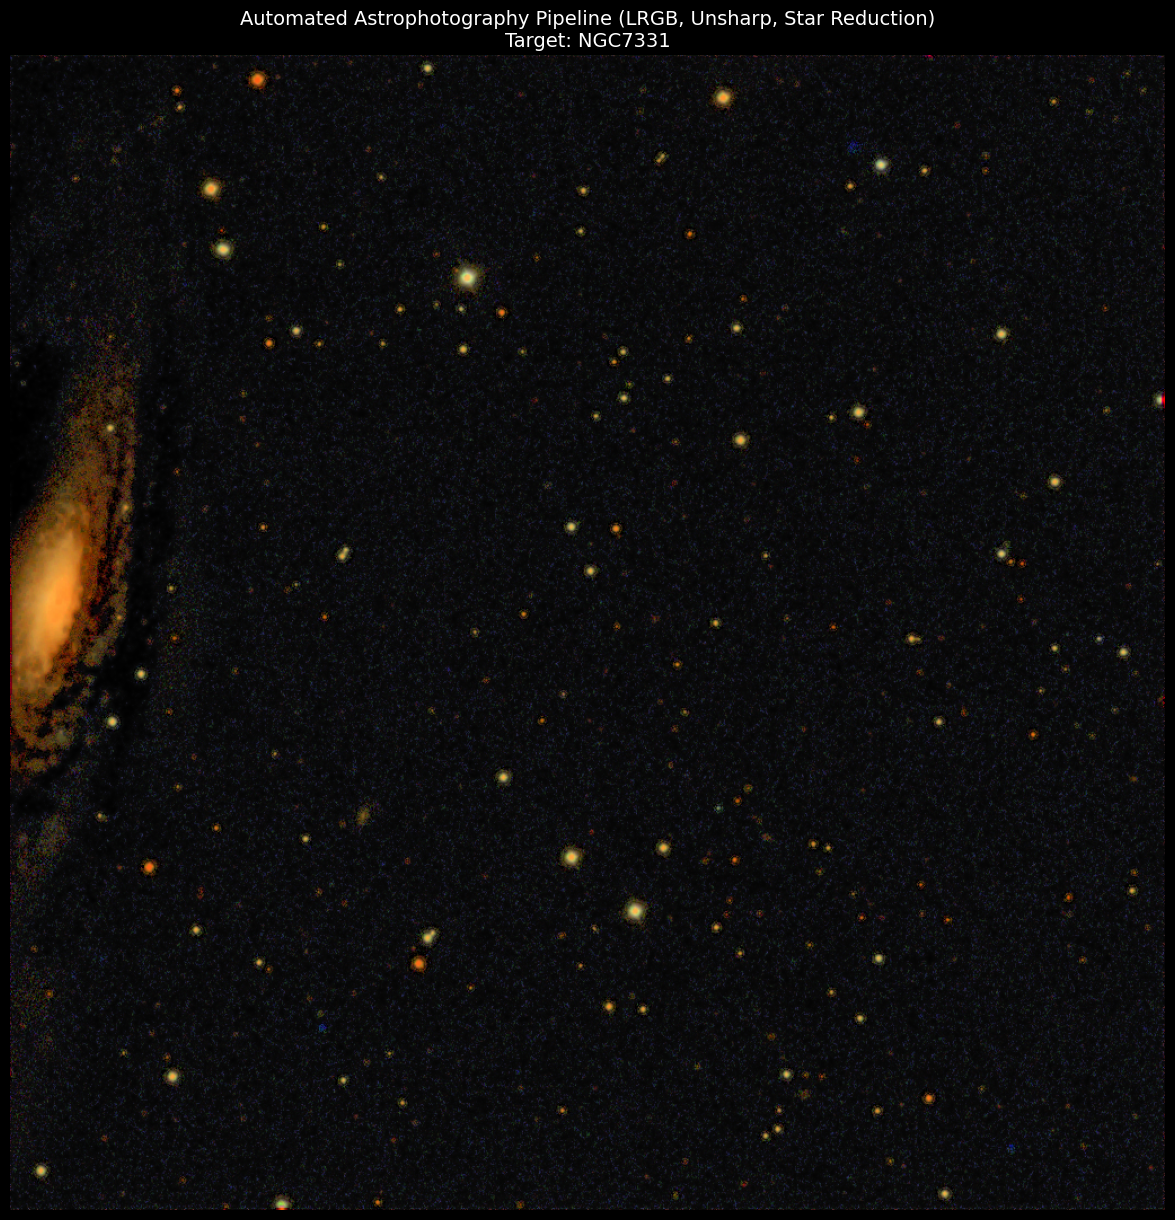

In [64]:
# CELL 9: Visualize the Result
plt.figure(figsize=(15, 15))
plt.title(f"Automated Astrophotography Pipeline (LRGB, Unsharp, Star Reduction)\nTarget: NGC7331", color='white', fontsize=14)
plt.imshow(final_rgb)
plt.axis('off')

# Change notebook background to dark
plt.gcf().set_facecolor('black')
plt.show()

In [65]:
# CELL 10: Export to Disk
# Save the final array as a high-resolution PNG

output_dir = os.path.dirname(r_file)
output_path = os.path.join(output_dir, "NGC7331_Final_Color_Aesthetic.png")

plt.imsave(output_path, final_rgb, origin='lower')
print(f"Success! Masterpiece saved to:\n{output_path}")

Success! Masterpiece saved to:
/media/plato/imtiaz/image_processing/NGC7331_thairobotic/Flux_calibrated/NGC7331_Final_Color_Aesthetic.png
